# SafeRL-Drive Phase-1 Colab driver

Use this notebook from VS Code with a Google Colab runtime. GitHub and `/content/safedrive` hold the live code. Google Drive holds persistent artifacts only at `/content/drive/MyDrive/SafeDrive`; do not run the repository from mounted Drive.

The smoke test, IDM baseline, PPO training, and SAC training are separate sections so long experiments can run in different Colab sessions. After every major experiment, copy its run directory to Drive. Set `FULL_TIMESTEPS = 1_000_000` in Section 1 only if you intentionally want a longer run.

## 1. Initialization

In [12]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/djdhillxn/safedrive.git"
REPO_DIR = Path("/content/safedrive")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT = DRIVE_MOUNT / "MyDrive" / "SafeDrive"
PILOT_TIMESTEPS = 100_000
FULL_TIMESTEPS = 500_000
TEST_START_SEED = 3000
TEST_EPISODES = 100
VIDEO_STEPS = 1000

print(f"Live checkout: {REPO_DIR}")
print(f"Artifact backup: {DRIVE_PROJECT}")
print(f"Training timesteps: {FULL_TIMESTEPS:,}")

Live checkout: /content/safedrive
Artifact backup: /content/drive/MyDrive/SafeDrive
Training timesteps: 500,000


## 2. Runtime and GPU check

In [13]:
import torch

print(f"Python: {sys.version.split()[0]}")
if shutil.which("nvidia-smi"):
    subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], check=False
    )
else:
    print("nvidia-smi: unavailable")

if torch.cuda.is_available():
    print(f"PyTorch CUDA: available ({torch.cuda.get_device_name(0)})")
else:
    print("PyTorch CUDA: unavailable; MLP training can still run on CPU.")

Python: 3.12.13
PyTorch CUDA: available (NVIDIA L4)


## 3. Mount Google Drive

In [14]:
from google.colab import drive

drive.mount(str(DRIVE_MOUNT))
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
connection_file = DRIVE_PROJECT / "colab_connection_test.txt"
connection_file.write_text(
    f"Connected at {datetime.now(timezone.utc).isoformat()}\n",
    encoding="utf-8",
)
print(f"Drive read/write ready: {connection_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive read/write ready: /content/drive/MyDrive/SafeDrive/colab_connection_test.txt


## 4. Clone or pull the repository

The repository is public, so no GitHub token is required. Push local changes before this step when Colab needs the newest revision.

In [15]:
if (REPO_DIR / ".git").exists():
    git_command = ["git", "-C", str(REPO_DIR), "pull", "--ff-only"]
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository.")
else:
    if REPO_DIR.exists():
        REPO_DIR.rmdir()
    git_command = ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)]

git_result = subprocess.run(git_command, capture_output=True, text=True)
if git_result.returncode:
    print(git_result.stdout[-4000:])
    print(git_result.stderr[-4000:])
    raise RuntimeError("Git clone/pull failed; see the output above.")

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
git_commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print(f"Repository ready at commit {git_commit[:12]}")

Repository ready at commit b453a1638ece


## 4.1 Restore run artifacts from Drive

Run the shared Drive-to-local sync command. In Colab this performs a full restore, including model files required for evaluation and videos, into `/content/safedrive/runs`. On your Mac, `python -m scripts.sync_drive_runs` defaults to a lightweight analysis-only mirror containing configs, metrics, logs, plots, and videos. Both uses preserve local-only files and rebuild latest-run pointers.

In [24]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "scripts.sync_drive_runs",
        "--drive-project",
        str(DRIVE_PROJECT),
        "--local-runs",
        str(REPO_DIR / "runs"),
        "--include-training-artifacts",
    ],
    cwd=REPO_DIR,
    check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'scripts.sync_drive_runs', '--drive-project', '/content/drive/MyDrive/SafeDrive', '--local-runs', '/content/safedrive/runs'], returncode=0)

## 5. Install SafeRL-Drive

In [16]:
import importlib.metadata

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "gym"],
    check=False,
    capture_output=True,
    text=True,
)
install_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--disable-pip-version-check",
        "--progress-bar",
        "off",
        "-e",
        ".",
    ],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
)
if install_result.returncode:
    print(install_result.stdout[-8000:])
    print(install_result.stderr[-8000:])
    raise RuntimeError("SafeRL-Drive installation failed; see the output above.")

packages = ["metadrive-simulator", "stable-baselines3", "gymnasium", "torch"]
versions = {name: importlib.metadata.version(name) for name in packages}
print(json.dumps(versions, indent=2))

{
  "metadrive-simulator": "0.4.3",
  "stable-baselines3": "2.9.0",
  "gymnasium": "1.3.0",
  "torch": "2.11.0+cu128"
}


### Shared artifact helpers

In [17]:
def read_latest_run(name):
    pointer = REPO_DIR / "runs" / f"latest_{name}.txt"
    if not pointer.exists():
        raise FileNotFoundError(f"Latest-run pointer not found: {pointer}")
    run_dir = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_dir.is_absolute():
        run_dir = REPO_DIR / run_dir
    return run_dir.resolve()


def require_shell_success(label):
    exit_code = get_ipython().user_ns.get("_exit_code", 0)
    if exit_code:
        raise RuntimeError(f"{label} failed with exit code {exit_code}.")


def require_learning_gate(run_dir, label, minimum_success=0.10, minimum_route=0.50):
    summary_path = Path(run_dir) / "eval" / "best_validation_summary.json"
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    success = float(summary.get("success_rate", 0.0))
    route = float(summary.get("mean_route_completion", 0.0))
    if success < minimum_success or route < minimum_route:
        raise RuntimeError(
            f"{label} pilot did not pass: success={success:.1%}, route={route:.1%}. "
            "Do not spend compute on the full run; inspect and share this pilot."
        )
    diagnostics_path = Path(run_dir) / "logs" / "training_diagnostics.json"
    if diagnostics_path.exists():
        history = json.loads(diagnostics_path.read_text(encoding="utf-8")).get("history", [])
        critic_losses = [row.get("train/critic_loss") for row in history]
        critic_losses = [float(value) for value in critic_losses if value is not None]
        if critic_losses and (
            not all(value == value and abs(value) != float("inf") for value in critic_losses)
            or abs(critic_losses[-1]) > 1000
        ):
            raise RuntimeError(
                f"{label} pilot critic is unstable: final loss {critic_losses[-1]:.3g}."
            )
    print(f"{label} pilot passed: success={success:.1%}, route={route:.1%}.")
    return summary


def show_json(path):
    path = Path(path)
    print(json.dumps(json.loads(path.read_text(encoding="utf-8")), indent=2))


def copy_to_drive(path, category="runs"):
    path = Path(path)
    target = DRIVE_PROJECT / category / path.name
    target.parent.mkdir(parents=True, exist_ok=True)
    if path.is_dir():
        target.mkdir(parents=True, exist_ok=True)
        if shutil.which("rsync"):
            subprocess.run(["rsync", "-a", f"{path}/", f"{target}/"], check=True)
        else:
            shutil.copytree(path, target, dirs_exist_ok=True)
    else:
        shutil.copy2(path, target)
    print(f"Copied to Drive: {target}")
    return target

## 6. Smoke test

This is only an installation/wiring check and is not a report result.

In [7]:
!python -m scripts.train --config configs/smoke_test.yaml
require_shell_success("Smoke test")

SMOKE_RUN_DIR = read_latest_run("smoke")
!python -m scripts.evaluate --run-dir "{SMOKE_RUN_DIR}" --model best --split test --episodes 2 --prefix best_test
require_shell_success("Smoke held-out evaluation")
show_json(SMOKE_RUN_DIR / "eval" / "best_test_summary.json")
copy_to_drive(SMOKE_RUN_DIR, category="smoke_tests")

2026-07-21 21:49:35.714158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 21:49:35.783932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_214939_smoke_test_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Fu

PosixPath('/content/drive/MyDrive/SafeDrive/smoke_tests/20260721_214939_smoke_test_ppo_seed0')

## 7. Deterministic IDM reproducibility gate

In [8]:
!python -m scripts.evaluate_baseline --config configs/ppo_mvp.yaml --split validation --episodes 10 --prefix idm_repro --verify-repeat
require_shell_success("IDM reproducibility gate")
print(
    "IDM reproducibility gate passed. The held-out IDM test runs after both learned configurations are frozen."
)

2026-07-21 21:52:13.717972: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 21:52:13.786808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_215217_idm_baseline_seed0
INFO: Evaluating IDMPolicy for 10 episodes on the validation split beginning at seed 1000.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use 

## 7.1 Short learning gates

Run these inexpensive no-traffic control pilots before either full experiment. Each pilot uses the corrected task and reward but writes to its own latest pointer. A full run is blocked unless its pilot reaches at least 10% success and 50% route completion on fixed validation scenarios. A failed gate is useful evidence; copy that pilot to Drive and diagnose it instead of spending hours on another blind run.

In [22]:
PPO_PILOT_RUN_DIR

PosixPath('/content/safedrive/runs/20260721_215328_ppo_control_pilot_ppo_seed0')

In [23]:
!python -m scripts.train --config configs/ppo_mvp.yaml --run-name ppo_control_pilot experiment.latest_name=ppo_pilot train.total_timesteps={PILOT_TIMESTEPS} train.checkpoint_freq=25000 train.eval_freq=25000 validation.episodes=20 metadrive.traffic_density=0.0 metadrive.random_traffic=false validation.traffic_density=0.0
require_shell_success("PPO diagnostic pilot")
PPO_PILOT_RUN_DIR = read_latest_run("ppo_pilot")
copy_to_drive(PPO_PILOT_RUN_DIR)
require_learning_gate(PPO_PILOT_RUN_DIR, "PPO")

2026-07-21 23:07:51.395433: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 23:07:51.465569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_230755_ppo_control_pilot_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1

RuntimeError: PPO pilot did not pass: success=0.0%, route=3.6%. Do not spend compute on the full run; inspect and share this pilot.

In [18]:
!python -m scripts.sync_drive_runs

Drive source: /content/drive/MyDrive/SafeDrive/runs
Local destination: /content/safedrive/runs
Sync complete: 267 files updated across 9 run directories.
Latest IDM: /content/safedrive/runs/20260721_181208_idm_baseline_seed0
Latest PPO: /content/safedrive/runs/20260721_090542_ppo_mvp_ppo_seed0
Latest PPO_PILOT: /content/safedrive/runs/20260721_215328_ppo_control_pilot_ppo_seed0
Latest SAC: /content/safedrive/runs/20260721_105717_sac_mvp_sac_seed0
Latest SMOKE: /content/safedrive/runs/20260721_214939_smoke_test_ppo_seed0


In [ ]:
!python -m scripts.train --config configs/sac_mvp.yaml --run-name sac_control_pilot experiment.latest_name=sac_pilot train.total_timesteps={PILOT_TIMESTEPS} train.checkpoint_freq=25000 train.eval_freq=25000 validation.episodes=20 metadrive.traffic_density=0.0 metadrive.random_traffic=false validation.traffic_density=0.0
require_shell_success("SAC diagnostic pilot")
SAC_PILOT_RUN_DIR = read_latest_run("sac_pilot")
copy_to_drive(SAC_PILOT_RUN_DIR)
require_learning_gate(SAC_PILOT_RUN_DIR, "SAC")

## 8. PPO training

In [ ]:
PPO_PILOT_RUN_DIR = read_latest_run("ppo_pilot")
require_learning_gate(PPO_PILOT_RUN_DIR, "PPO")
!python -m scripts.train --config configs/ppo_mvp.yaml train.total_timesteps={FULL_TIMESTEPS} test.episodes={TEST_EPISODES}
require_shell_success("PPO training")

PPO_RUN_DIR = read_latest_run("ppo")
ppo_summary = PPO_RUN_DIR / "eval" / "best_validation_summary.json"
print(f"PPO run: {PPO_RUN_DIR}")
print(f"PPO summary: {ppo_summary}")
show_json(ppo_summary)
copy_to_drive(PPO_RUN_DIR)

2026-07-21 09:05:38.476264: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 09:05:38.546920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_090542_ppo_mvp_ppo_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Futur

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_090542_ppo_mvp_ppo_seed0')

## 9. SAC training

In [7]:
SAC_PILOT_RUN_DIR = read_latest_run("sac_pilot")
require_learning_gate(SAC_PILOT_RUN_DIR, "SAC")
!python -m scripts.train --config configs/sac_mvp.yaml train.total_timesteps={FULL_TIMESTEPS} test.episodes={TEST_EPISODES}
require_shell_success("SAC training")

SAC_RUN_DIR = read_latest_run("sac")
sac_summary = SAC_RUN_DIR / "eval" / "best_validation_summary.json"
print(f"SAC run: {SAC_RUN_DIR}")
print(f"SAC summary: {sac_summary}")
show_json(sac_summary)
copy_to_drive(SAC_RUN_DIR)

2026-07-21 10:57:13.299655: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 10:57:13.370321: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_105717_sac_mvp_sac_seed0
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: Futur

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_105717_sac_mvp_sac_seed0')

## 10. Inspect held-out PPO and SAC tests

Training freezes the best validation checkpoint without touching the held-out test. Run this once after both full configurations are frozen; it also backfills an older run if needed. Seeds 3000--3099 are the new untouched test set.

In [9]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

print(PPO_RUN_DIR, SAC_RUN_DIR)

/content/safedrive/runs/20260721_090542_ppo_mvp_ppo_seed0 /content/safedrive/runs/20260721_105717_sac_mvp_sac_seed0


In [10]:
PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")

idm_pointer = REPO_DIR / "runs" / "latest_idm.txt"
idm_test_ready = False
if idm_pointer.exists():
    IDM_RUN_DIR = Path(idm_pointer.read_text(encoding="utf-8").strip())
    if not IDM_RUN_DIR.is_absolute():
        IDM_RUN_DIR = REPO_DIR / IDM_RUN_DIR
    idm_test_ready = (IDM_RUN_DIR / "eval" / "idm_test_summary.json").exists()
if not idm_test_ready:
    !python -m scripts.evaluate_baseline --config configs/ppo_mvp.yaml --split test --episodes {TEST_EPISODES} --prefix idm_test
    require_shell_success("IDM held-out test")
    IDM_RUN_DIR = read_latest_run("idm")
show_json(IDM_RUN_DIR / "eval" / "idm_test_summary.json")
copy_to_drive(IDM_RUN_DIR)

for label, run_dir in [("PPO", PPO_RUN_DIR), ("SAC", SAC_RUN_DIR)]:
    test_summary = run_dir / "eval" / "best_test_summary.json"
    if not test_summary.exists():
        # Backfill old runs that predate the validation/test split.
        !python -m scripts.evaluate --run-dir "{run_dir}" --model best --split test --episodes {TEST_EPISODES} --prefix best_test test.start_seed={TEST_START_SEED} test.num_scenarios=100 test.random_traffic=false test.random_spawn_lane_index=false
        require_shell_success(f"{label} held-out test evaluation")
    print(f"{label} held-out result: {test_summary}")
    show_json(test_summary)

copy_to_drive(PPO_RUN_DIR)
copy_to_drive(SAC_RUN_DIR)

2026-07-21 18:12:03.837551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 18:12:03.907954: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Run directory: runs/20260721_181208_idm_baseline_seed0
INFO: Evaluating IDMPolicy for 100 episodes on the test split beginning at seed 2000.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the c

PosixPath('/content/drive/MyDrive/SafeDrive/runs/20260721_105717_sac_mvp_sac_seed0')

## 11. Record one rollout per trained agent

The notebook chooses a successful held-out scenario when one exists, otherwise the test scenario with the greatest route completion. The exact seed and outcome are saved beside the MP4.

In [12]:
import csv

PPO_RUN_DIR = read_latest_run("ppo")
SAC_RUN_DIR = read_latest_run("sac")


def choose_video_seed(run_dir):
    episode_path = run_dir / "eval" / "best_test_episodes.csv"
    with episode_path.open(newline="", encoding="utf-8") as file:
        rows = list(csv.DictReader(file))
    successful = [row for row in rows if row["success"].lower() == "true"]
    candidates = successful or rows
    selected = max(candidates, key=lambda row: float(row["route_completion"]))
    return int(float(selected["env_seed"])), bool(successful)


for label, run_dir in [("PPO", PPO_RUN_DIR), ("SAC", SAC_RUN_DIR)]:
    video_seed, is_success = choose_video_seed(run_dir)
    print(f"{label} video seed: {video_seed}; successful test rollout: {is_success}")
    !python -m scripts.record_video --run-dir "{run_dir}" --model best --seed {video_seed} --steps {VIDEO_STEPS}
    require_shell_success(f"{label} video")
    copy_to_drive(run_dir)

PPO video seed: 2065; successful test rollout: True
2026-07-21 18:47:07.227437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 18:47:07.297751: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
INFO: Loading best model on cpu for deterministic scenario

RuntimeError: PPO video failed with exit code 1.

## 12. Compare IDM, PPO, and SAC

INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Phase-1 comparison written: runs/phase1_comparison.csv
INFO: Comparison plot written: runs/phase1_comparison.png
INFO: Training comparison written: runs/phase1_training_returns.png


,name,episodes,mean_return,std_return,mean_length,success_rate,success_rate_95ci_low,success_rate_95ci_high,collision_rate,out_of_road_rate,timeout_or_max_step_rate,mean_cost,mean_route_completion,mean_speed_km_h,run_dir,summary_path
0,IDM,100,403.302645,204.335587,550.77,0.38,2.909760e-01,0.477902,0.56,0.02,0.04,0.58,0.705787,7.487241,/content/safedrive/runs/20260721_181208_idm_ba...,/content/safedrive/runs/20260721_181208_idm_ba...
1,PPO,100,121.528035,124.860250,340.77,0.04,1.566330e-02,0.098371,0.10,0.75,0.11,0.85,0.324993,6.890425,/content/safedrive/runs/20260721_090542_ppo_mv...,/content/safedrive/runs/20260721_090542_ppo_mv...
2,SAC,100,69.289845,67.236247,945.02,0.00,3.469447e-18,0.036993,0.00,0.07,0.93,0.07,0.154609,0.991013,/content/safedrive/runs/20260721_105717_sac_mv...,/content/safedrive/runs/20260721_105717_sac_mv...


{
  "generated_at_utc": "2026-07-21T18:47:23.367615+00:00",
  "experiments": [
    {
      "name": "IDM",
      "episodes": 100,
      "mean_return": 403.3026447561248,
      "std_return": 204.3355870605433,
      "mean_length": 550.77,
      "success_rate": 0.38,
      "success_rate_95ci_low": 0.29097599252478734,
      "success_rate_95ci_high": 0.47790244704488916,
      "collision_rate": 0.56,
      "out_of_road_rate": 0.02,
      "timeout_or_max_step_rate": 0.04,
      "mean_cost": 0.58,
      "mean_route_completion": 0.7057871321959969,
      "mean_speed_km_h": 7.487241073782172,
      "run_dir": "/content/safedrive/runs/20260721_181208_idm_baseline_seed0",
      "summary_path": "/content/safedrive/runs/20260721_181208_idm_baseline_seed0/eval/idm_test_summary.json"
    },
    {
      "name": "PPO",
      "episodes": 100,
      "mean_return": 121.5280348188985,
      "std_return": 124.86024983765077,
      "mean_length": 340.77,
      "success_rate": 0.04,
      "success_rate_95ci_

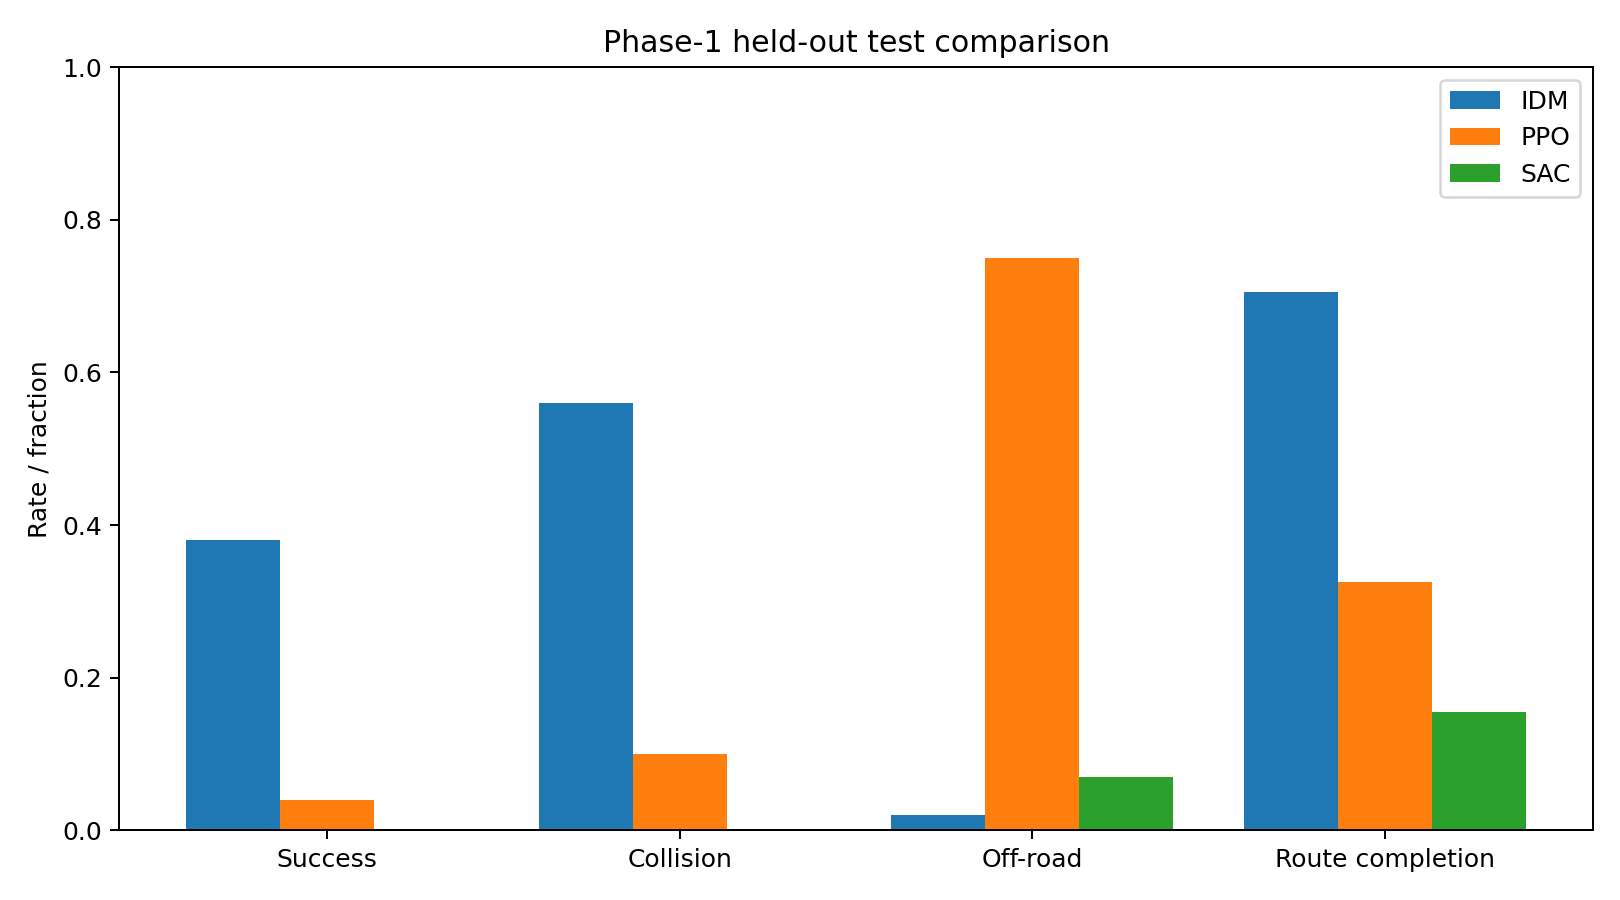

Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.csv
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.json
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.png
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_training_returns.png


In [13]:
import pandas as pd
from IPython.display import Image, display

!python -m scripts.compare_runs --phase1
require_shell_success("Phase-1 comparison")

comparison_csv = REPO_DIR / "runs" / "phase1_comparison.csv"
comparison_json = REPO_DIR / "runs" / "phase1_comparison.json"
comparison_png = REPO_DIR / "runs" / "phase1_comparison.png"
display(pd.read_csv(comparison_csv))
show_json(comparison_json)
display(Image(filename=str(comparison_png)))

for path in [comparison_csv, comparison_json, comparison_png]:
    copy_to_drive(path)
training_comparison = REPO_DIR / "runs" / "phase1_training_returns.png"
if training_comparison.exists():
    copy_to_drive(training_comparison)

INFO: Runtime: Python 3.12.13 | CUDA available | GPU NVIDIA L4
INFO: Phase-1 comparison written: runs/phase1_comparison.csv
INFO: Comparison plot written: runs/phase1_comparison.png
INFO: Training comparison written: runs/phase1_training_returns.png


,name,episodes,mean_return,std_return,mean_length,success_rate,collision_rate,out_of_road_rate,timeout_or_max_step_rate,mean_cost,mean_route_completion,mean_speed_km_h,run_dir,summary_path
0,IDM,50,394.488521,241.378332,526.26,0.50,0.28,0.20,0.02,0.48,0.696618,27.046089,/content/safedrive/runs/20260721_023109_idm_ba...,/content/safedrive/runs/20260721_023109_idm_ba...
1,PPO,50,254.318737,161.518255,578.56,0.16,0.12,0.54,0.18,0.66,0.597896,23.863502,/content/safedrive/runs/20260721_023556_ppo_mv...,/content/safedrive/runs/20260721_023556_ppo_mv...
2,SAC,50,63.006623,65.336449,905.16,0.00,0.00,0.14,0.86,0.14,0.174585,4.218184,/content/safedrive/runs/20260721_032424_sac_mv...,/content/safedrive/runs/20260721_032424_sac_mv...


{
  "generated_at_utc": "2026-07-21T06:34:17.836754+00:00",
  "experiments": [
    {
      "name": "IDM",
      "episodes": 50,
      "mean_return": 394.48852090106493,
      "std_return": 241.37833241859207,
      "mean_length": 526.26,
      "success_rate": 0.5,
      "collision_rate": 0.28,
      "out_of_road_rate": 0.2,
      "timeout_or_max_step_rate": 0.02,
      "mean_cost": 0.48,
      "mean_route_completion": 0.6966180358737663,
      "mean_speed_km_h": 27.04608873858742,
      "run_dir": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0",
      "summary_path": "/content/safedrive/runs/20260721_023109_idm_baseline_seed0/eval/idm_unseen_summary.json"
    },
    {
      "name": "PPO",
      "episodes": 50,
      "mean_return": 254.3187371043007,
      "std_return": 161.51825477257682,
      "mean_length": 578.56,
      "success_rate": 0.16,
      "collision_rate": 0.12,
      "out_of_road_rate": 0.54,
      "timeout_or_max_step_rate": 0.18,
      "mean_cost": 0.66,
   

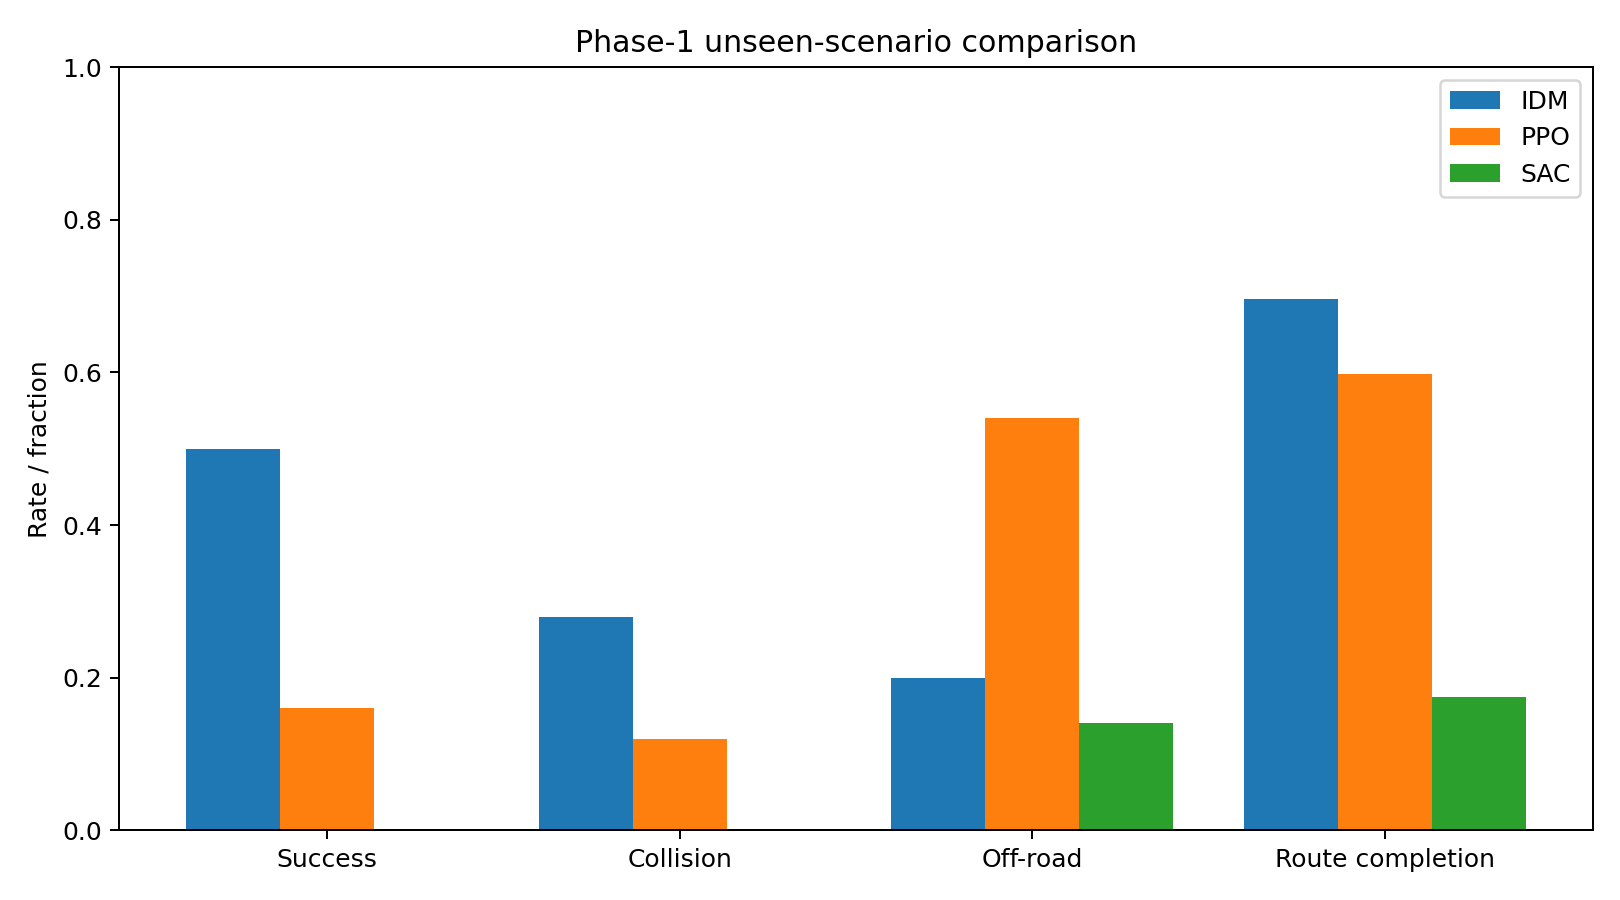

Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.csv
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.json
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_comparison.png
Copied to Drive: /content/drive/MyDrive/SafeDrive/runs/phase1_training_returns.png


In [13]:
import pandas as pd
from IPython.display import Image, display

!python -m scripts.compare_runs --phase1
require_shell_success("Phase-1 comparison")

comparison_csv = REPO_DIR / "runs" / "phase1_comparison.csv"
comparison_json = REPO_DIR / "runs" / "phase1_comparison.json"
comparison_png = REPO_DIR / "runs" / "phase1_comparison.png"
display(pd.read_csv(comparison_csv))
show_json(comparison_json)
display(Image(filename=str(comparison_png)))

for path in [comparison_csv, comparison_json, comparison_png]:
    copy_to_drive(path)
training_comparison = REPO_DIR / "runs" / "phase1_training_returns.png"
if training_comparison.exists():
    copy_to_drive(training_comparison)

## 13. Build the LaTeX report

In [14]:
if shutil.which("latexmk"):
    !latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex
    require_shell_success("LaTeX report build")
else:
    print("latexmk is not installed in this runtime. Build locally from the repository root with:")
    print("latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex")

report_pdf = REPO_DIR / "reports" / "main.pdf"
if report_pdf.exists():
    copy_to_drive(report_pdf, category="reports")

latexmk is not installed in this runtime. Build locally from the repository root with:
latexmk -pdf -interaction=nonstopmode -halt-on-error reports/main.tex


## 14. Final artifact sync

In [20]:
(DRIVE_PROJECT / "runs").mkdir(parents=True, exist_ok=True)
(DRIVE_PROJECT / "reports").mkdir(parents=True, exist_ok=True)

if shutil.which("rsync"):
    !rsync -a "{REPO_DIR}/runs/" "{DRIVE_PROJECT}/runs/"
    require_shell_success("Run artifact sync")
    !rsync -a "{REPO_DIR}/reports/" "{DRIVE_PROJECT}/reports/"
    require_shell_success("Report artifact sync")
else:
    shutil.copytree(REPO_DIR / "runs", DRIVE_PROJECT / "runs", dirs_exist_ok=True)
    shutil.copytree(REPO_DIR / "reports", DRIVE_PROJECT / "reports", dirs_exist_ok=True)

print(f"Final artifact sync complete: {DRIVE_PROJECT}")

Final artifact sync complete: /content/drive/MyDrive/SafeDrive


## Finished

The detailed execution record is inside each run's `logs/` directory and `run_metadata.json`. Disconnect the Colab runtime when finished so it does not continue consuming compute units.